# Analise do Impacto da IA nos Alunos

### Integrantes: 

- **Gabriel Angel dos Santos Sousa**

- **Jorge Batista Santos Júnior**

---

### Fonte dos Dados

#### **Kagle**

#### Dataset [link do dataset](https://www.kaggle.com/datasets/laveshjadon/ai-impact-on-students/data)
---

### Objetivo

#### Treinar um modelo que seja capaz de preditar o nivel do risco de Burnout que um aluno pode ter com base nos dados
---

### Atributo-Alvo 

#### **Burnout_Risk_Level** (Nível de Risco de Bornout)
---

### Atributos Preditivos


| Atributos Preditivos |
|----------|
|  Student_ID  |
| Major_Category   |
| Year_of_Study   |
| Pre_Semester_GPA   |
| Weekly_GenAI_Hours   |
| Primary_Use_Case  |
| Prompt_Engineering_Skill   |
| Tool_Diversity   |
| Paid_Subscription   |
| Traditional_Study_Hours   |
| Perceived_AI_Dependency   |
| Institutional_Policy   |
| Anxiety_Level_During_Exams   |
| Post_Semester_GPA   |
| Skill_Retention_Score   |

---

### Tipo de Tarefa

#### **Classificação**
---

---
# Importando **Dataset**


In [1]:
# importar libs do kaggle para baixar os datasets

import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "ai_student_impact_dataset (1).csv"

df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "laveshjadon/ai-impact-on-students",
  file_path,
)

/home/angel/python/datasets/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/tmp/ipykernel_353931/1051907880.py:8: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


--- 
# Análise dos Dados 

5.2 Compreensão dos dados
Apresentar e discutir:
• quantidade de registros e atributos;
• tipos das variáveis;
• valores ausentes;
• duplicações;
• inconsistências;
• distribuição do atributo-alvo;
• desbalanceamento, quando houver.

In [ ]:
# Quantidade de objetos e atributos

df.shape

(50000, 16)

Comente aqui jorge

In [9]:
df.head()

,Student_ID,Major_Category,Year_of_Study,Pre_Semester_GPA,Weekly_GenAI_Hours,Primary_Use_Case,Prompt_Engineering_Skill,Tool_Diversity,Paid_Subscription,Traditional_Study_Hours,Perceived_AI_Dependency,Institutional_Policy,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score,Burnout_Risk_Level
0,100001,Humanities,Senior,2.418,23.31,Copywriting/Drafting,Beginner,1,True,8.13,5,Allowed_With_Citation,6,2.393,86.44,High
1,100002,Medical,Junior,3.821,1.12,Ideation,Advanced,5,False,16.65,3,Allowed_With_Citation,9,3.696,69.39,Low
2,100003,Business,Freshman,3.398,21.26,Summarizing_Reading,Beginner,2,False,10.35,5,Strict_Ban,9,3.499,73.93,Medium
3,100004,Business,Senior,3.789,1.82,Copywriting/Drafting,Intermediate,4,False,15.23,2,Allowed_With_Citation,2,4.000,63.58,Medium
4,100005,STEM,Sophomore,3.635,9.29,Debugging/Troubleshooting,Advanced,4,False,12.55,4,Allowed_With_Citation,4,3.798,100.00,Medium


Comente aqui jorge

In [4]:
# Informações gerais

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Student_ID                  50000 non-null  int64  
 1   Major_Category              50000 non-null  object 
 2   Year_of_Study               50000 non-null  object 
 3   Pre_Semester_GPA            50000 non-null  float64
 4   Weekly_GenAI_Hours          50000 non-null  float64
 5   Primary_Use_Case            50000 non-null  object 
 6   Prompt_Engineering_Skill    50000 non-null  object 
 7   Tool_Diversity              50000 non-null  int64  
 8   Paid_Subscription           50000 non-null  bool   
 9   Traditional_Study_Hours     50000 non-null  float64
 10  Perceived_AI_Dependency     50000 non-null  int64  
 11  Institutional_Policy        50000 non-null  object 
 12  Anxiety_Level_During_Exams  50000 non-null  int64  
 13  Post_Semester_GPA           500

comente aqui jorge

In [5]:
# Estatísticas das variáveis categóricas


df.describe(include='object')

,Major_Category,Year_of_Study,Primary_Use_Case,Prompt_Engineering_Skill,Institutional_Policy,Burnout_Risk_Level
count,50000,50000,50000,50000,50000,50000
unique,5,5,5,3,3,3
top,STEM,Junior,Debugging/Troubleshooting,Beginner,Allowed_With_Citation,Medium
freq,15059,11045,12295,18495,25224,21144


comente aqui jorge

In [6]:
# Estatísticas das variáveis numéricas

df.describe()

,Student_ID,Pre_Semester_GPA,Weekly_GenAI_Hours,Tool_Diversity,Traditional_Study_Hours,Perceived_AI_Dependency,Anxiety_Level_During_Exams,Post_Semester_GPA,Skill_Retention_Score
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,125000.500000,3.146102,8.427752,2.80026,11.209271,3.505360,4.270760,3.349299,75.798125
std,14433.901067,0.478854,8.269490,1.18802,5.156426,1.820812,2.144066,0.495673,13.281626
min,100001.000000,1.183000,0.000000,1.00000,1.000000,1.000000,1.000000,1.000000,10.780000
25%,112500.750000,2.834000,2.390000,2.00000,7.560000,2.000000,3.000000,3.023750,66.820000
50%,125000.500000,3.210000,5.800000,3.00000,11.180000,3.000000,4.000000,3.421000,76.000000
75%,137500.250000,3.521000,11.720000,4.00000,14.710000,5.000000,6.000000,3.749000,85.190000
max,150000.000000,3.998000,40.000000,5.00000,35.860000,10.000000,10.000000,4.000000,100.000000


In [7]:
# distribuição das classes de Burnout_Risk_Level (em porcentagem)

df["Burnout_Risk_Level"].value_counts(normalize=True) * 100

Burnout_Risk_Level
Medium    42.288
Low       32.738
High      24.974
Name: proportion, dtype: float64

comente aqui jorge

### Atributos

#### Através de uma análise percebemos:

1. Burnout_Risk_Level que será nosso target (alvo) está razoalvemente balanceado:

Burnout_Risk_Level

- Medium      |     42.288
- Low         |     32.738
- High        |     24.974

---

2. Os atributos:
- Post_Semester_GPA
- Skill_Retention_Score

São data leakage e não podem entrar no treinamento do modelo




In [ ]:
atributos = [
    "Major_Category",
    "Year_of_Study",
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Tool_Diversity",
    "Paid_Subscription",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Institutional_Policy",
    "Anxiety_Level_During_Exams",
    "Post_Semester_GPA",
    "Burnout_Risk_Level"
]

students = df.loc[:, atributos]

---
# Análise exploratória

## Analizando o Target

#### Para melhor entendimento da variável alvo é necessário um gráfico

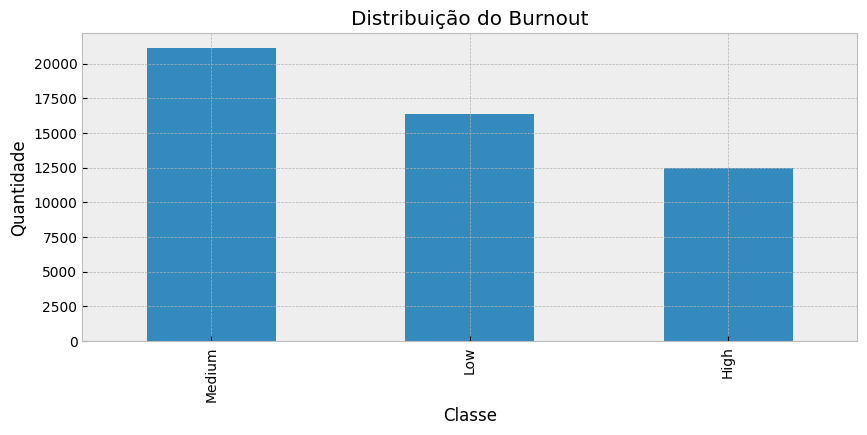

In [10]:
import matplotlib.pyplot as plt

burnout_counts = df["Burnout_Risk_Level"].value_counts()

plt.style.use('bmh')

plt.figure(figsize=(10,4))
burnout_counts.plot(kind="bar")

plt.title("Distribuição do Burnout")
plt.xlabel("Classe")
plt.ylabel("Quantidade")

plt.show()

In [ ]:
numeric_cols = [
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Tool_Diversity",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams"
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for ax, col in zip(axes.flat, numeric_cols):
    ax.hist(df[col], bins=30)
    ax.set_title(col)

plt.tight_layout()
plt.show()

## Análise de Outliers

#### Através dos gráficos das variáveis numéricas achamos alguns valores loge da média sim mas que são totalmente plausíveis no contexto da nossa análise e que ainda pode ajudar na predição do modelo. Portanto, não há necessidade de limpar os dados.

In [ ]:
plt.style.use('bmh')
fig, axes = plt.subplots(2,3, figsize=(15,8))

for ax, col in zip(axes.flat, numeric_cols):
    ax.boxplot(df[col])
    ax.set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8,5))

df.boxplot(
    column="Weekly_GenAI_Hours",
    by="Burnout_Risk_Level"
)

plt.suptitle("")
plt.title("Horas de IA por nível de Burnout")

plt.show()

In [ ]:
import pandas as pd

pd.crosstab(
    df["Major_Category"],
    df["Burnout_Risk_Level"],
    normalize="index"
)

In [ ]:
corr = df[numeric_cols].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.show()

# Hipótese


Segundo a análise dos gráficos podemos formular a seguinte hipótese:

#### Alunos classificados com nível alto de burnout tendem a usar IA por mais horas semanais

# Construindo o Modelo

In [ ]:
# Separando os dados de treino do target (alvo)

X = students.drop(columns=["Burnout_Risk_Level"])
y = students["Burnout_Risk_Level"]

In [ ]:
# Separar os dados de treino dos de teste

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)



#### Precisamos transformar atributos categóricos em numéricos pois os modelos só trabalham dessa forma. Usando One-Hot Encoding

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

categorical_features = [
    "Major_Category",
    "Year_of_Study",
    "Primary_Use_Case",
    "Prompt_Engineering_Skill",
    "Institutional_Policy"
]

numeric_features = [
    "Pre_Semester_GPA",
    "Weekly_GenAI_Hours",
    "Tool_Diversity",
    "Traditional_Study_Hours",
    "Perceived_AI_Dependency",
    "Anxiety_Level_During_Exams",
    "Paid_Subscription"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("num", "passthrough", numeric_features)
    ]
)

### Árvore de Decisão

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier

modelo = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", DecisionTreeClassifier(
            max_depth=5,
            min_samples_leaf=20,
            random_state=42
        ))
    ]
)

In [ ]:
# Treinamento

modelo.fit(X_train, y_train)

In [ ]:
# Predição

y_pred = modelo.predict(X_test)

In [ ]:
# Probabilidades

y_prob = modelo.predict_proba(X_test)

In [ ]:
# Avaliação do modelo

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print(accuracy*100)

Podemos ver que a acurácia do modelo é em torno de 43.8 % 

In [ ]:
# Avaliação mais detalhada

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

In [ ]:
# Matriz de confusão

from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [ ]:
# Análise de Overfitting

train_score = modelo.score(X_train, y_train)

test_score = modelo.score(X_test, y_test)

print(train_score*100)
print(test_score*100)

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = Pipeline(
    steps=[
        ("preprocessamento", preprocessor),
        ("modelo", RandomForestClassifier(
                n_estimators=300,
                max_depth=10,
                min_samples_leaf=10,
                min_samples_split=20,
                max_features="sqrt",
                random_state=42

        ))
    ]
)

In [ ]:
modelo_rf.fit(X_train, y_train)

In [ ]:
y_pred = modelo_rf.predict(X_test)

In [ ]:
from sklearn.metrics import confusion_matrix


print(classification_report(y_test, y_pred))

print(confusion_matrix(y_test, y_pred))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    cmap="Blues"
)

In [ ]:
train_score = modelo_rf.score(X_train, y_train)
test_score = modelo_rf.score(X_test, y_test)

print(f"Treino: {train_score:.2%}")
print(f"Teste : {test_score:.2%}")

In [ ]:
import pandas as pd

rf = modelo_rf.named_steps["modelo"]

feature_names = modelo_rf.named_steps[
    "preprocessamento"
].get_feature_names_out()

importancias = pd.DataFrame({
    "Feature": feature_names,
    "Importancia": rf.feature_importances_
})

importancias = importancias.sort_values(
    by="Importancia",
    ascending=False
)

print(importancias.head(15))

# Conclusão

Foram feitos vários testes com dois modelos e com mudanças de hiperparâmetros e a melhora de performance (acurácia) foi menos de 10%.
Observamos que alguns atributos como:

- Weekly_GenAI_Hours
- Perceived_AI_Dependency

Esses atributos tomaram conta da decisão do modelo. O Weekly_GenAI_Hours tomou aproximadamente 45% da importância da predição e o Perceived_AI_Dependency 18%.

O dataset pode ter sido construído de forma artificial para estudos, pois as classes de Burnout_Risk_Level estão muito balanceadas - quase 33% para cada classe - e não há dados vazios. Isso pode atrapalhar a predição do modelo podendo ocorrer overfitting. 


Em síntese, o modelo de Random Forest teve uma acurácia de 53% de acerto que para nosso caso é péssimo por prever o possível risco de burnout.